In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import shutil

pd.set_option('display.max_columns', None)

### My results (AHT-DCT)

In [6]:
results_df = pd.read_csv("results.csv", header=0)
results_df["bpp2"] = results_df["bpp"] / 2

results_df.head(50)

,arch,model,lmbda,test_date,bpp,psnr_iq,msssim_iq,psnr_amp,sqnr_amp,msssim_amp,mae_phase,enc_time,dec_time,total_kmac_per_px,enc_kmac_per_px,dec_kmac_per_px,ga_kmac_per_px,ha_kmac_per_px,gs_kmac_per_px,hs_kmac_per_px,total_params,energy_1,energy_2,energy_3,energy_4,bpp2
0,AHT,baseline,0.0018,20260220,0.716621,22.062682,0.770009,18.524360,5.743769,0.755006,1.363722,0.006088,0.006679,25.4195,10.4795,14.940,10.000,0.4795,11.440,3.5,3501266,0.934997,0.307669,0.202932,0.077065,0.358311
1,AHT,baseline,0.0035,20260220,1.096727,24.190743,0.859740,21.235688,8.447391,0.852234,1.057849,0.006106,0.006668,25.4195,10.4795,14.940,10.000,0.4795,11.440,3.5,3501266,0.871433,0.587294,0.400163,0.268575,0.548363
2,AHT,baseline,0.0067,20260220,1.520224,26.248949,0.915178,23.453195,10.668876,0.906888,0.831701,0.006176,0.006741,25.4195,10.4795,14.940,10.000,0.4795,11.440,3.5,3501266,1.853931,1.077474,0.744773,0.514317,0.760112
3,AHT,baseline,0.0130,20260220,1.952077,28.200985,0.951350,25.467825,12.760107,0.940352,0.658586,0.006020,0.005407,25.4195,10.4795,14.940,10.000,0.4795,11.440,3.5,3501266,3.608068,2.031043,1.321878,0.936594,0.976038
4,AHT,baseline,0.0250,20260220,2.418229,30.211926,0.972008,27.502110,14.921223,0.963622,0.517907,0.006100,0.005501,25.4195,10.4795,14.940,10.000,0.4795,11.440,3.5,3501266,7.527685,3.766488,2.342698,2.083508,1.209115
5,AHT,baseline,0.0483,20260220,2.846333,31.886251,0.982857,29.165390,16.758823,0.976630,0.419285,0.006094,0.005592,25.4195,10.4795,14.940,10.000,0.4795,11.440,3.5,3501266,15.254996,6.925618,4.141081,3.754731,1.423167
6,AHT,DCT,0.0018,20260220,0.740558,22.284382,0.786171,18.936660,6.183614,0.778250,1.326793,0.007095,0.007116,21.9035,9.3755,12.528,8.896,0.4795,9.028,3.5,3514344,1.019882,0.291241,0.201968,0.108682,0.370279
7,AHT,DCT,0.0035,20260220,1.095668,24.249200,0.860670,21.340137,8.558794,0.856144,1.050535,0.007024,0.007160,21.9035,9.3755,12.528,8.896,0.4795,9.028,3.5,3514344,0.908422,0.574327,0.402717,0.272208,0.547834
8,AHT,DCT,0.0067,20260220,1.509625,26.251905,0.915072,23.512533,10.746760,0.907223,0.832624,0.007047,0.006174,21.9035,9.3755,12.528,8.896,0.4795,9.028,3.5,3514344,1.873953,1.112649,0.753837,0.518465,0.754813
9,AHT,DCT,0.0130,20260220,1.953476,28.290424,0.950452,25.590904,12.879481,0.941672,0.657043,0.007017,0.006125,21.9035,9.3755,12.528,8.896,0.4795,9.028,3.5,3514344,3.903035,2.122217,1.339490,1.012769,0.976738


### Data from Maharjan 2024 (ELIC-DCT)

In [24]:
rd_data = {
    # JPEG2000 (lowest BPP not shown in paper)
    "jpeg2000": {
        "bpp":  [2.6647 , 1.999  , 1.5992 , 0.9996 , 0.5323],
        "psnr": [28.925 , 24.4725, 22.2939, 18.6632, 15.3867],
        "sqnr": [18.4845, 14.1511, 11.9136, 8.3596 , 5.1653],
        "mape": [0.3918 , 0.6234 , 0.8121 , 1.1672 , 1.5330],
        "color":"#01b8aa",
        "marker": "^",
        "linestyle": "dashed",
    },
    # HEVC
    "hevc": {
        "bpp":  [2.8405 , 2.5788 , 1.9839 , 1.4525 , 0.9826 ],
        "psnr": [33.1111, 31.5369, 27.8776, 24.1401, 20.6104],
        "sqnr": [22.6497, 21.0718, 17.4426, 13.7223, 10.2396],
        "mape": [0.2195 , 0.2593 , 0.3812 , 0.5717 , 0.8370],
        "color":"#003f5c",
        "marker": "d",
        "linestyle": "dashed",
    },
    # LearnedIQ (Maharjan 2023)
    "learnediq": {
        "bpp":  [2.8405 , 2.5788 , 1.9839 , 1.4525 , 0.9826 ],
        "psnr": [34.3395, 32.9682, 29.4298, 25.3870, 21.5924],
        "sqnr": [23.9356, 22.5431, 18.9904, 14.9526, 11.1809],
        "mape": [0.1894 , 0.2232 , 0.3366 , 0.5202 , 0.7773],
        "color":"#20639b",
        "marker": "P",
        "linestyle": "dashed",
    },
    # VVC (lowest BPP not shown in paper)
    "vvc": {
        "bpp":  [2.8008 , 2.5111 , 1.98   , 1.4989 , 0.9148 , 0.5456 ],
        "psnr": [34.4543, 32.8780, 29.3566, 25.9315, 21.1603, 17.3979],
        "sqnr": [23.9722, 22.4221, 18.9250, 15.5249, 10.7797, 7.0912],
        "mape": [0.1867 , 0.2199 , 0.3190 , 0.4632 , 0.7914 , 1.1828],
        "color":"#9F2B68",
        "marker": "s",
        "linestyle": "dashed",
    },
    # ELIC-DCT (Maharjan 2024)
    "elicdct": {
        "bpp":  [2.9640 , 2.7782 , 2.5324 , 2.3432 , 1.9434 , 1.3604 ],
        "psnr": [39.0820, 38.6299, 37.3533, 36.2189, 33.2039, 27.8906],
        "sqnr": [30.6782, 29.6883, 27.9480, 26.5056, 23.0530, 17.5115],
        "mape": [0.0833 , 0.0936 , 0.1150 , 0.1364 , 0.2037 , 0.3796 ],
        "color":"#ed553b",
        "marker": "*",
        "linestyle": "dashed",
    },
}

### RD-Curve: AHT vs. codecs in Maharjan 2024

In [25]:
aht_data = results_df[results_df["model"] == "baseline"]
rd_data["aht_baseline"] = {
    "bpp": aht_data["bpp2"].round(4).tolist(),
    "psnr": aht_data["psnr_amp"].round(4).tolist(),
    "sqnr": aht_data["sqnr_amp"].round(4).tolist(),
    "mape": aht_data["mae_phase"].round(4).tolist(),
    "color": "#ffa600",
    "marker": "o",
    "linestyle": "solid",
}

In [26]:
rd_data["aht_dct"] = {
    "bpp":  [0.3876, 0.5784, 0.7321, 0.9595, 1.1210, 1.2375, 2.4289],
    "psnr": [19.2276, 21.4663, 23.0597, 25.2319, 26.6564, 27.4108, 33.1572],
    "sqnr": [6.8572, 8.9582, 10.5334, 12.7963, 14.3422, 15.3077, 23.4317],
    "mape": [1.1715, 0.9505, 0.8037, 0.6317, 0.5322, 0.4779, 0.2139],
    "color": "#1f77b4",
    "marker": "o",
    "linestyle": "solid",
}


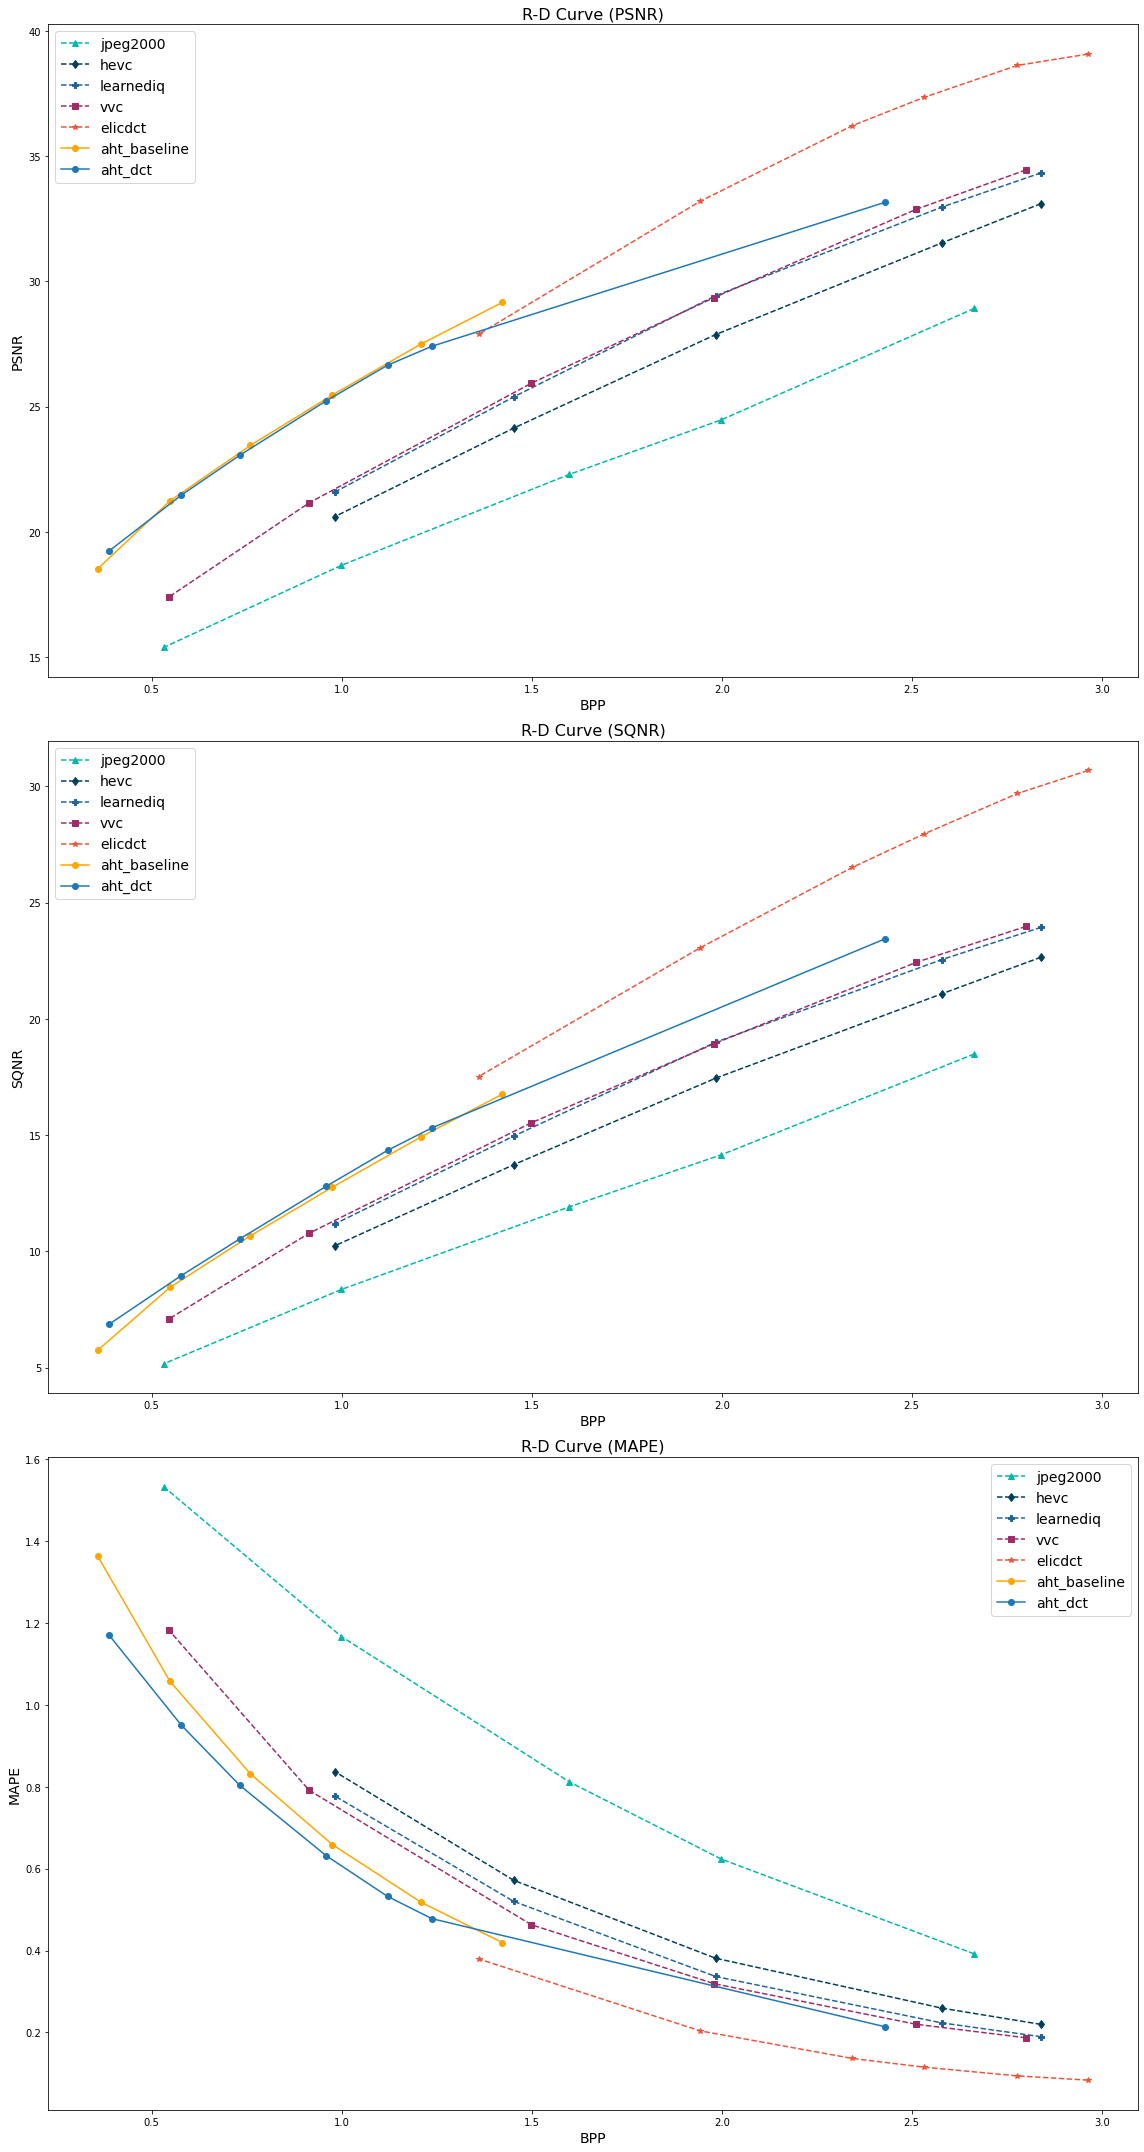

In [29]:
# Make 3 subplots for PSNR, SQNR, and MAPE
fig, ax = plt.subplots(3, 1, figsize=(16, 30))

ax[0].set_title("R-D Curve (PSNR)", fontsize=16)
ax[1].set_title("R-D Curve (SQNR)", fontsize=16)
ax[2].set_title("R-D Curve (MAPE)", fontsize=16)

for i, model in enumerate(rd_data.keys()):
    bpp = rd_data[model]["bpp"]
    psnr = rd_data[model]["psnr"]
    sqnr = rd_data[model]["sqnr"]
    mape = rd_data[model]["mape"]

    ax[0].plot(bpp, psnr, label=model, marker=rd_data[model]["marker"], linestyle=rd_data[model]["linestyle"], color=rd_data[model]["color"])
    ax[1].plot(bpp, sqnr, label=model, marker=rd_data[model]["marker"], linestyle=rd_data[model]["linestyle"], color=rd_data[model]["color"])
    ax[2].plot(bpp, mape, label=model, marker=rd_data[model]["marker"], linestyle=rd_data[model]["linestyle"], color=rd_data[model]["color"])

ax[0].set_xlabel("BPP", fontsize=14)
ax[0].set_ylabel("PSNR", fontsize=14)
ax[0].legend(fontsize=14)
ax[1].set_xlabel("BPP", fontsize=14)
ax[1].set_ylabel("SQNR", fontsize=14)
ax[1].legend(fontsize=14)
ax[2].set_xlabel("BPP", fontsize=14)
ax[2].set_ylabel("MAPE", fontsize=14)
ax[2].legend(fontsize=14)
plt.tight_layout()
plt.show()

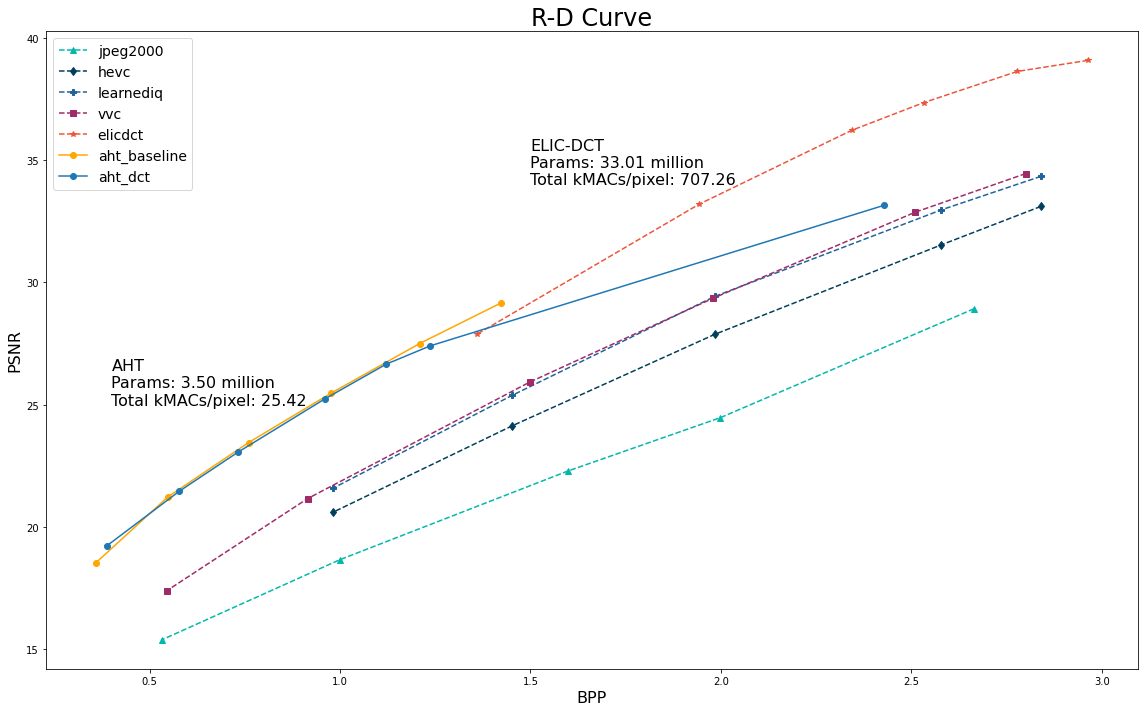

In [ ]:

fig, ax = plt.subplots(figsize=(16, 10))

for i, model in enumerate(rd_data.keys()):
    bpp = rd_data[model]["bpp"]
    psnr = rd_data[model]["psnr"]
    ax.plot(
        bpp, 
        psnr, 
        label=model, 
        marker=rd_data[model]["marker"], 
        linestyle=rd_data[model]["linestyle"],
        color=rd_data[model]["color"],
    )

ax.set_xlabel("BPP", fontsize=16)
ax.set_ylabel("PSNR", fontsize=16)
ax.set_title("R-D Curve (PSNR)", fontsize=24)
# plt.text(1.5, 34, "ELIC-DCT\nParams: 33.01 million\nTotal kMACs/pixel: 707.26", fontsize=16, color='black')
# plt.text(0.4, 25, "AHT\nParams: 3.50 million\nTotal kMACs/pixel: 25.42", fontsize=16, color='black')
ax.legend(fontsize=14)
plt.tight_layout()
plt.show()

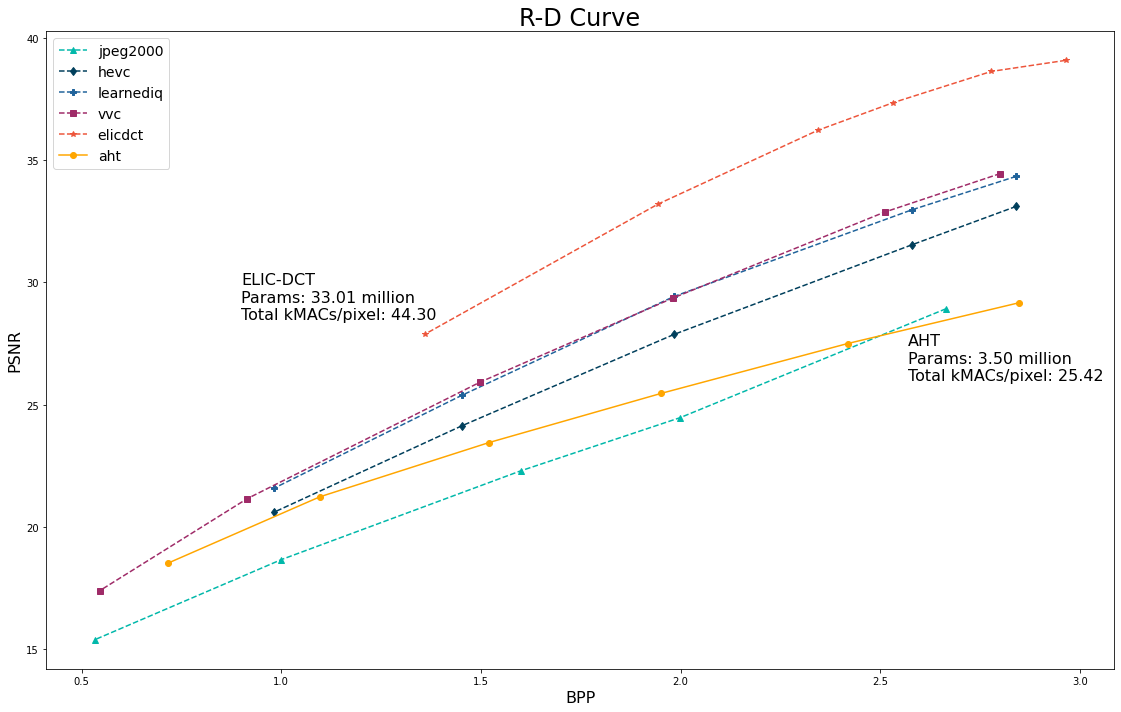

In [13]:
fig, ax = plt.subplots(figsize=(16, 10))

for i, model in enumerate(rd_data.keys()):
    bpp = rd_data[model]["bpp"]
    psnr = rd_data[model]["psnr"]
    ax.plot(
        bpp, 
        psnr, 
        label=model, 
        marker=rd_data[model]["marker"], 
        linestyle=rd_data[model]["linestyle"],
        color=rd_data[model]["color"],
    )

ax.set_xlabel("BPP", fontsize=16)
ax.set_ylabel("PSNR", fontsize=16)
ax.set_title("R-D Curve", fontsize=24)
plt.text(.9, 28.5, "ELIC-DCT\nParams: 33.01 million\nTotal kMACs/pixel: 44.30", fontsize=16, color='black')
plt.text(2.57, 26, "AHT\nParams: 3.50 million\nTotal kMACs/pixel: 25.42", fontsize=16, color='black')
ax.legend(fontsize=14)
plt.tight_layout()
plt.show()

# Amplitude PSNR

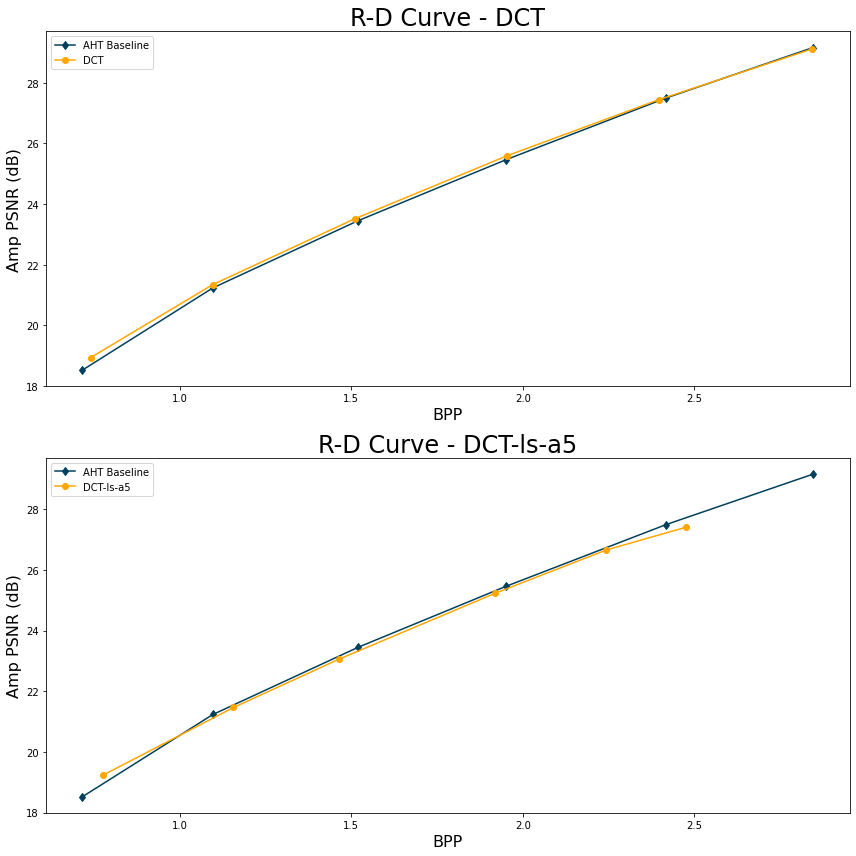

In [12]:
models = ["DCT", "DCT-ls-a5"]
fig, ax = plt.subplots(len(models), 1, figsize=(12, len(models)*6))

for i, model in enumerate(models):
    baseline_data = results_df[results_df["model"] == "baseline"]
    exp_data = results_df[results_df["model"] == model]
    ax[i].plot(baseline_data["bpp"], baseline_data["psnr_amp"], label="AHT Baseline", marker="d", color="#003f5c")
    ax[i].plot(exp_data["bpp"], exp_data["psnr_amp"], label=model, marker="o", color="#ffa600")
    ax[i].set_xlabel("BPP", fontsize=16)
    ax[i].set_ylabel("Amp PSNR (dB)", fontsize=16)
    ax[i].set_title(f"R-D Curve - {model}", fontsize=24)
    ax[i].legend()

plt.tight_layout()
plt.show()

# Amplitude SQNR

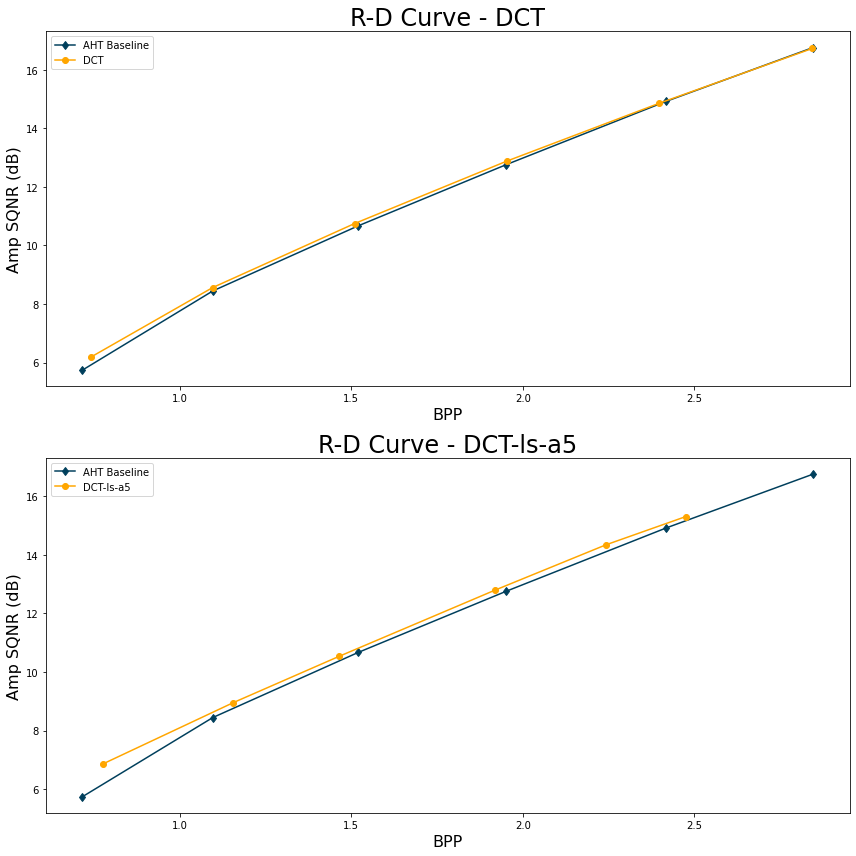

In [13]:

models = ["DCT", "DCT-ls-a5"]
fig, ax = plt.subplots(len(models), 1, figsize=(12, len(models)*6))

for i, model in enumerate(models):
    baseline_data = results_df[results_df["model"] == "baseline"]
    exp_data = results_df[results_df["model"] == model]
    ax[i].plot(baseline_data["bpp"], baseline_data["sqnr_amp"], label="AHT Baseline", marker="d", color="#003f5c")
    ax[i].plot(exp_data["bpp"], exp_data["sqnr_amp"], label=model, marker="o", color="#ffa600")
    ax[i].set_xlabel("BPP", fontsize=16)
    ax[i].set_ylabel("Amp SQNR (dB)", fontsize=16)
    ax[i].set_title(f"R-D Curve - {model}", fontsize=24)
    ax[i].legend()

plt.tight_layout()
plt.show()

# Phase MAE

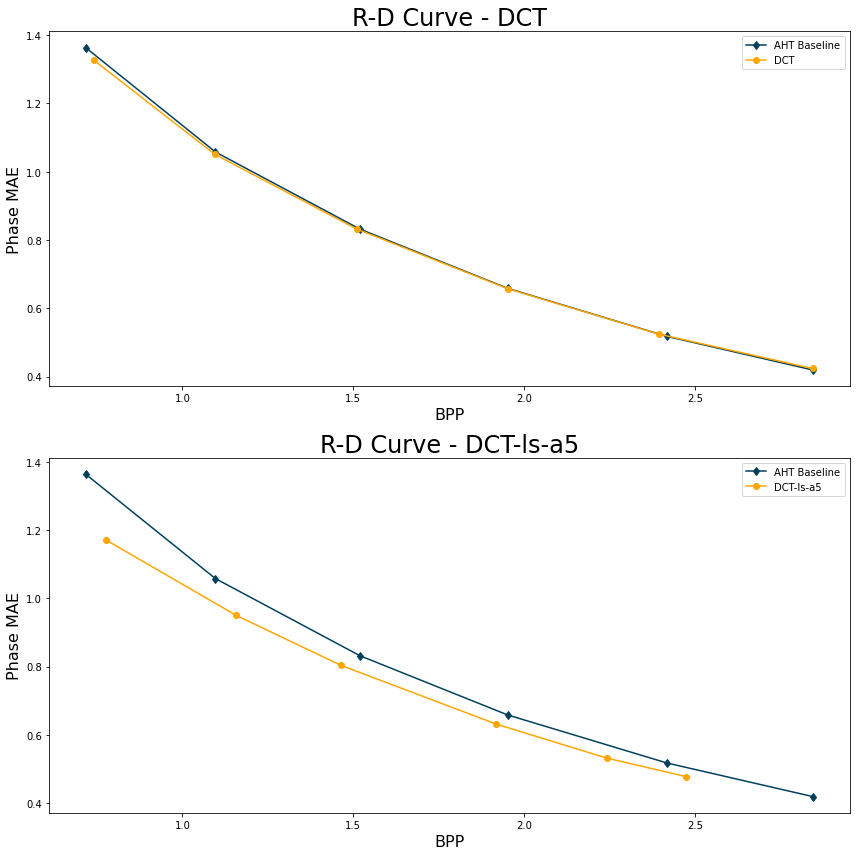

In [14]:
models = ["DCT", "DCT-ls-a5"]
fig, ax = plt.subplots(len(models), 1, figsize=(12, len(models)*6))

for i, model in enumerate(models):
    baseline_data = results_df[results_df["model"] == "baseline"]
    exp_data = results_df[results_df["model"] == model]
    ax[i].plot(baseline_data["bpp"], baseline_data["mae_phase"], label="AHT Baseline", marker="d", color="#003f5c")
    ax[i].plot(exp_data["bpp"], exp_data["mae_phase"], label=model, marker="o", color="#ffa600")
    ax[i].set_xlabel("BPP", fontsize=16)
    ax[i].set_ylabel("Phase MAE", fontsize=16)
    ax[i].set_title(f"R-D Curve - {model}", fontsize=24)
    ax[i].legend()

plt.tight_layout()
plt.show()

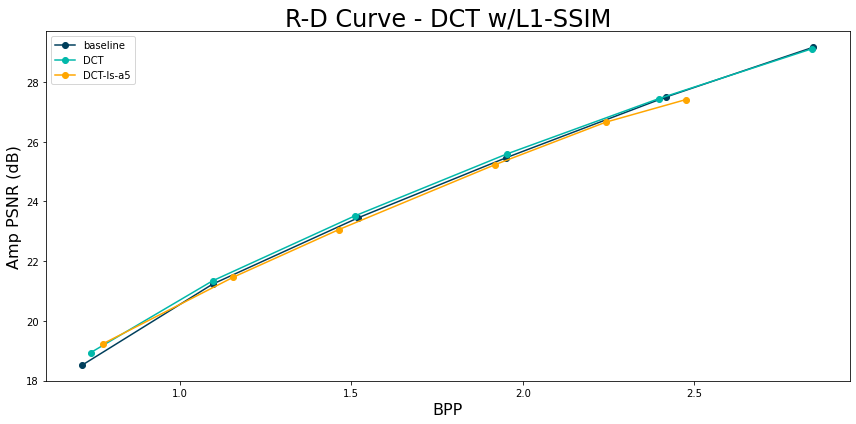

In [18]:
models = ["baseline", "DCT", "DCT-ls-a5"]
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
colors = ["#003f5c", "#01b8aa", "#ffa600"]

for i, model in enumerate(models):
    exp_data = results_df[results_df["model"] == model]
    ax.plot(exp_data["bpp"], exp_data["psnr_amp"], label=model, marker="o", color=colors[i])
    ax.set_xlabel("BPP", fontsize=16)
    ax.set_ylabel("Amp PSNR (dB)", fontsize=16)
    ax.set_title("R-D Curve - DCT w/L1-SSIM", fontsize=24)
    ax.legend()

plt.tight_layout()
plt.show()

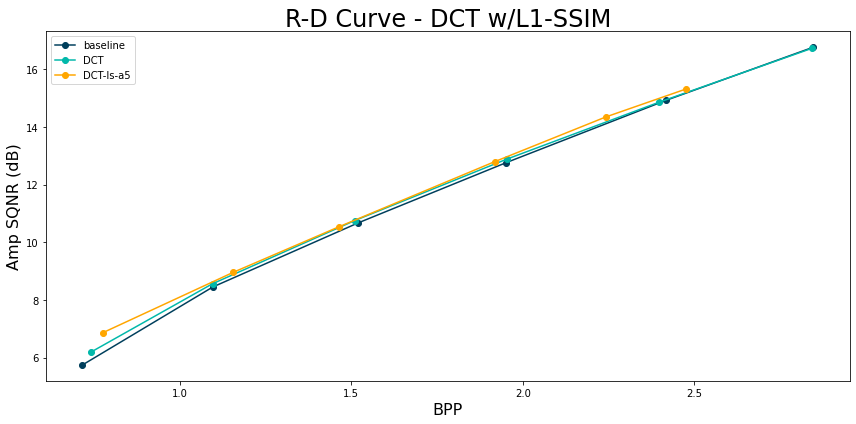

In [19]:
models = ["baseline", "DCT", "DCT-ls-a5"]
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
colors = ["#003f5c", "#01b8aa", "#ffa600"]

for i, model in enumerate(models):
    exp_data = results_df[results_df["model"] == model]
    ax.plot(exp_data["bpp"], exp_data["sqnr_amp"], label=model, marker="o", color=colors[i])
    ax.set_xlabel("BPP", fontsize=16)
    ax.set_ylabel("Amp SQNR (dB)", fontsize=16)
    ax.set_title("R-D Curve - DCT w/L1-SSIM", fontsize=24)
    ax.legend()

plt.tight_layout()
plt.show()

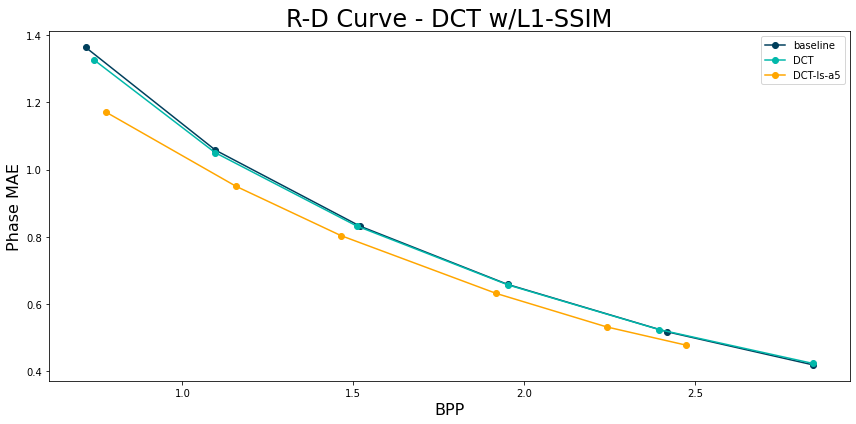

In [20]:
models = ["baseline", "DCT", "DCT-ls-a5"]
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
colors = ["#003f5c", "#01b8aa", "#ffa600"]

for i, model in enumerate(models):
    exp_data = results_df[results_df["model"] == model]
    ax.plot(exp_data["bpp"], exp_data["mae_phase"], label=model, marker="o", color=colors[i])
    ax.set_xlabel("BPP", fontsize=16)
    ax.set_ylabel("Phase MAE", fontsize=16)
    ax.set_title("R-D Curve - DCT w/L1-SSIM", fontsize=24)
    ax.legend()

plt.tight_layout()
plt.show()

# Analysis of Tokens

Normalized SAR Image:
-- Shape: torch.Size([1, 2, 256, 256]) | Range: [0.0000, 1.0000]
DCT Tokens:
-- Shape: torch.Size([1, 32, 64, 64]) | Range: [-1.1140, 2.9335]


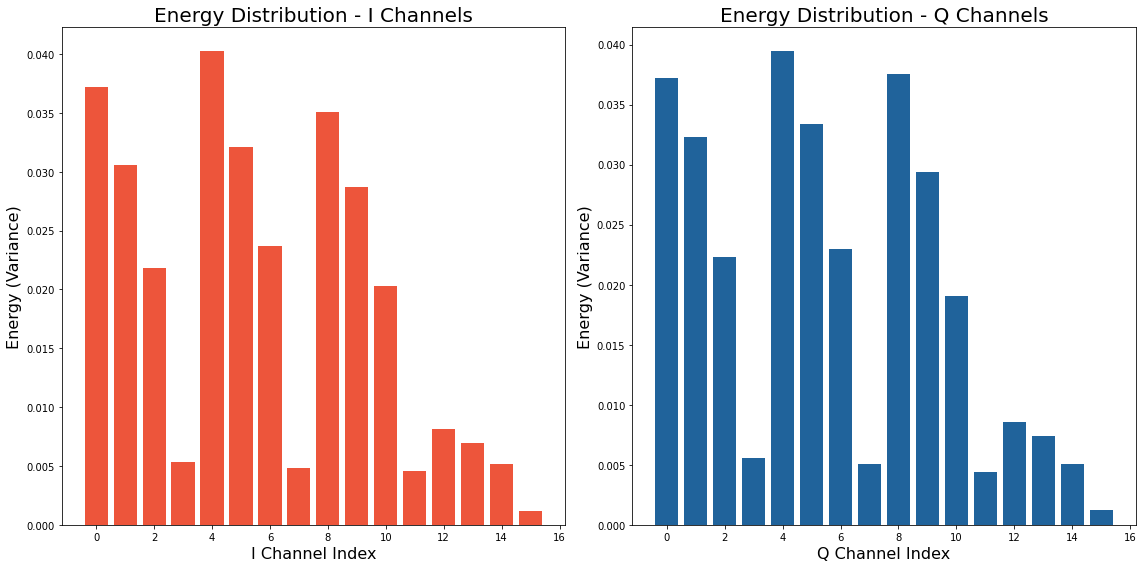

In [30]:
from src.utils.dct import ImageDCT
from test import load_image

inp = "/scratch/zb7df/data/NGA/multi_pol/validation/gt_HH/0.npy"
block = 4

img = load_image(inp)
dct_util = ImageDCT(block_size=block)
dc_ac = dct_util.dct_2d(img)

print("Normalized SAR Image:")
print(f"-- Shape: {img.shape} | Range: [{img.min().item():.4f}, {img.max().item():.4f}]")
print("DCT Tokens:")
print(f"-- Shape: {dc_ac.shape} | Range: [{dc_ac.min().item():.4f}, {dc_ac.max().item():.4f}]")

# Take variance across spatial dimensions for each channel
channel_energy = dc_ac.var(dim=[2, 3])
channel_energy_I = channel_energy[:, :16]
channel_energy_Q = channel_energy[:, 16:]

# # Plot energy distribution across I channels
# plt.figure(figsize=(12, 6))
# plt.bar(range(channel_energy.shape[1]), channel_energy[0].cpu().numpy(), color="#ed553b")
# plt.xlabel("Channel Index", fontsize=16)
# plt.ylabel("Energy (Variance)", fontsize=16)
# plt.title("Energy Distribution Across DCT Channels", fontsize=24)
# plt.tight_layout()
# plt.show()

# Plot energy distributions for I and Q channels in subplots
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.bar(range(channel_energy_I.shape[1]), channel_energy_I[0].cpu().numpy(), color="#ed553b")
plt.xlabel("I Channel Index", fontsize=16)
plt.ylabel("Energy (Variance)", fontsize=16)
plt.title("Energy Distribution - I Channels", fontsize=20)
plt.subplot(1, 2, 2)
plt.bar(range(channel_energy_Q.shape[1]), channel_energy_Q[0].cpu().numpy(), color="#20639b")
plt.xlabel("Q Channel Index", fontsize=16)
plt.ylabel("Energy (Variance)", fontsize=16)
plt.title("Energy Distribution - Q Channels", fontsize=20)
plt.tight_layout()
plt.show()

In [ ]:
k = 8
in_channels = 32
out_channels = 64

energy_df = pd.DataFrame({"channel": list(range(channel_energy.shape[1])), "energy": channel_energy.flatten()})
energy_df = energy_df.sort_values(by="energy", ascending=False).reset_index(drop=True)
energy_df["energy_prop"] = energy_df["energy"] / energy_df["energy"].sum()

conn = k * out_channels
conn_adj = conn - (k * in_channels)
energy_df["connections"] = (energy_df["energy_prop"] * conn)
energy_df["connections_int"] = energy_df["connections"].round().astype(int)
energy_df["connections_adj"] = (energy_df["energy_prop"] * conn_adj) + k
energy_df["connections_adj_int"] = energy_df["connections_adj"].round().astype(int)
energy_df.loc[0, "connections_adj_int"] = energy_df.loc[0, "connections_adj_int"] - (energy_df["connections_adj_int"].sum() - conn)

print(energy_df["connections_int"].sum())
print(energy_df["connections_adj_int"].sum())
energy_df

# min 4

512
512


,channel,energy,energy_prop,connections,connections_int,connections_adj,connections_adj_int
0,4,0.040253,0.065273,33.419853,33,24.709927,26
1,20,0.039462,0.063991,32.763226,33,24.381613,24
2,24,0.037534,0.060865,31.162998,31,23.581499,24
3,16,0.037230,0.060371,30.909962,31,23.454981,23
4,0,0.037220,0.060355,30.901646,31,23.450823,23
5,8,0.035111,0.056935,29.150715,29,22.575357,23
6,21,0.033365,0.054105,27.701591,28,21.850796,22
7,17,0.032327,0.052420,26.839205,27,21.419601,21
8,5,0.032079,0.052019,26.633577,27,21.316788,21
9,1,0.030548,0.049536,25.362358,25,20.681179,21


In [37]:
logdir = "/scratch/zb7df/checkpoints/AHT_DCT"
dest = "/home/zb7df/dev/AHT_DCT/training_logs"

for folder in os.listdir(logdir):
    folder_path = os.path.join(logdir, folder)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if file.startswith("events.out.tfevents"):
                src_file = os.path.join(folder_path, file)
                os.makedirs(os.path.join(dest, folder), exist_ok=True)
                dest_file = os.path.join(dest, f"{folder}/{file}")
                shutil.copy(src_file, dest_file)
                print(f"Copied {src_file} to {dest_file}")

Copied /scratch/zb7df/checkpoints/AHT_DCT/AHT_DCT-exp2_lmbda0.025_20260127/events.out.tfevents.1769494055.kc-sse-ml-rn04.329343.0 to /home/zb7df/dev/AHT_DCT/training_logs/AHT_DCT-exp2_lmbda0.025_20260127/events.out.tfevents.1769494055.kc-sse-ml-rn04.329343.0
Copied /scratch/zb7df/checkpoints/AHT_DCT/AHT_DCT_lmbda0.0035_20260126/events.out.tfevents.1769454850.kc-sse-ml-rn04.4054197.0 to /home/zb7df/dev/AHT_DCT/training_logs/AHT_DCT_lmbda0.0035_20260126/events.out.tfevents.1769454850.kc-sse-ml-rn04.4054197.0
Copied /scratch/zb7df/checkpoints/AHT_DCT/AHT_DCT_lmbda0.0035_20260126/events.out.tfevents.1769454492.kc-sse-ml-rn04.4050119.0 to /home/zb7df/dev/AHT_DCT/training_logs/AHT_DCT_lmbda0.0035_20260126/events.out.tfevents.1769454492.kc-sse-ml-rn04.4050119.0
Copied /scratch/zb7df/checkpoints/AHT_DCT/AHT_DCT_uneven_lmbda0.0067_20260128/events.out.tfevents.1769661596.kc-sse-ml-rn04.1082873.0 to /home/zb7df/dev/AHT_DCT/training_logs/AHT_DCT_uneven_lmbda0.0067_20260128/events.out.tfevents.1769

In [ ]:
# orig = (x * 10000) - 5000
# orig = torch.sqrt(torch.sum(orig ** 2, dim=1, keepdim=True))
# orig_amp_db = 20 * torch.log10(orig_amp + 1e-6)
# orig = orig.squeeze().cpu().numpy()
# vmin, vmax = np.percentile(orig_amp, [0, 100])
# print(orig_amp.shape)
# plt.imshow(orig_amp, cmap='gray', vmin=vmin, vmax=vmax)
# plt.show()